# USCRN paper workflow master

This notebook builds the full paper workflow from the cleaned long USCRN table.

## Outputs
- **Figure 1**: correlation between 5 cm soil moisture and deeper soil moisture across daily, weekly, monthly, and seasonal timescales
- **Figure 2**: grouped boxplot of SM–VPD correlation across timescales, colored by depth, with station counts
- **Figure 3**: joint daily SM–VPD distributions by depth across all sites
- **Figure 4**: numerical soil moisture depth-mismatch experiment figure showing recovered VPD and soil moisture coefficients and model fit

## Active-period definition
A day is retained if:
- tmax > 5
- vpd > 0.5
- precipitation is ≤1 mm on the current and following day

This notebook assumes you already created a cleaned long table and station metadata file.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
# ----------------------------
# User choices
# ----------------------------
RAIN_THRESH = 1.0          # mm
ACTIVE_TMAX_MIN = 5.0      # deg C
ACTIVE_VPD_MIN = 0.5       # kPa

def format_thresh(val):
    if val == 0:
        return "0"
    return str(val).replace(".", "")

TSTR = f"T{format_thresh(ACTIVE_TMAX_MIN)}"
VSTR = f"VPD{format_thresh(ACTIVE_VPD_MIN)}"
PSTR = f"P{format_thresh(RAIN_THRESH)}"

SUFFIX = f"{TSTR}_{VSTR}_{PSTR}"
print(SUFFIX)

T50_VPD05_P10


In [3]:
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 140,
})

DATA_DIR = Path("uscrn_processed")
OUT_DIR = Path("outputs/paper_workflow")
FIG_DIR = OUT_DIR / "figures"
TAB_DIR = OUT_DIR / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

LONG_TABLE = DATA_DIR / "uscrn_daily_long_2000_2026.parquet"   # edit if needed
STATION_META = DATA_DIR / "uscrn_station_metadata.parquet"      # edit if needed


## Load data

In [4]:
df = pd.read_parquet(LONG_TABLE)
station_meta = pd.read_parquet(STATION_META)

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["station_id", "date"]).reset_index(drop=True)
print(df.columns.tolist())
required_cols = [
    "station_id", "date", "lat", "lon", "tmax", "vpd",
    "sm_5", "sm_10", "sm_20", "sm_50", "sm_100"
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df.head()

['station_id', 'wban', 'date', 'year', 'month', 'doy', 'lat', 'lon', 'lat_round', 'lon_round', 'tmax', 'tmin', 'tavg', 'ppt', 'solarad', 'rh_max', 'rh_min', 'rh_avg', 'vpd', 'vpdmean', 'sm_5', 'sm_10', 'sm_20', 'sm_50', 'sm_100', 'st_5', 'st_10', 'st_20', 'st_50', 'st_100', 'source_file', 'source_stem', 'source_year_dir', 'CRX_VN', 'T_DAILY_MEAN', 'SUR_TEMP_DAILY_TYPE', 'SUR_TEMP_DAILY_MAX', 'SUR_TEMP_DAILY_MIN', 'SUR_TEMP_DAILY_AVG']


,station_id,wban,date,year,month,doy,lat,lon,lat_round,lon_round,...,st_100,source_file,source_stem,source_year_dir,CRX_VN,T_DAILY_MEAN,SUR_TEMP_DAILY_TYPE,SUR_TEMP_DAILY_MAX,SUR_TEMP_DAILY_MIN,SUR_TEMP_DAILY_AVG
0,0,3047,2003-05-21,2003,5,141,31.62,-102.81,31.62,-102.81,...,NaN,CRND0103-2003-TX_Monahans_6_ENE.txt,CRND0103-2003-TX_Monahans_6_ENE,2003,1.001,NaN,U,NaN,NaN,NaN
1,0,3047,2003-05-22,2003,5,142,31.62,-102.81,31.62,-102.81,...,NaN,CRND0103-2003-TX_Monahans_6_ENE.txt,CRND0103-2003-TX_Monahans_6_ENE,2003,1.001,20.0,R,NaN,NaN,22.8
2,0,3047,2003-05-23,2003,5,143,31.62,-102.81,31.62,-102.81,...,NaN,CRND0103-2003-TX_Monahans_6_ENE.txt,CRND0103-2003-TX_Monahans_6_ENE,2003,1.001,26.6,R,NaN,NaN,29.4
3,0,3047,2003-05-24,2003,5,144,31.62,-102.81,31.62,-102.81,...,NaN,CRND0103-2003-TX_Monahans_6_ENE.txt,CRND0103-2003-TX_Monahans_6_ENE,2003,1.001,28.5,R,NaN,NaN,27.5
4,0,3047,2003-05-25,2003,5,145,31.62,-102.81,31.62,-102.81,...,NaN,CRND0103-2003-TX_Monahans_6_ENE.txt,CRND0103-2003-TX_Monahans_6_ENE,2003,1.001,21.9,R,NaN,NaN,24.8


## Build active-period subset

This is the shared analysis dataset for Figures 1–4.


In [5]:
# ----------------------------
# Define CONUS mask if not already present
# ----------------------------
mask_conus = (
    df["lon"].between(-125, -66) &
    df["lat"].between(24, 50)
)

# ----------------------------
# Rain flags
# ----------------------------
df["is_rain"] = df["ppt"] > RAIN_THRESH

# previous day rain, by station
df["rain_prev_day"] = (df.groupby("station_id")["is_rain"]
                         .shift(1).fillna(False).astype(bool))

# ----------------------------
# Seasonal / meteorological filters
# ----------------------------
mask_may_sep = df["month"].between(5, 9)
mask_active = (
    (df["tmax"] > ACTIVE_TMAX_MIN) &
    (df["vpd"] > ACTIVE_VPD_MIN)
)

# ----------------------------
# Final clean mask
# May-Sep only
# exclude rain day
# exclude day after rain
# ----------------------------
mask_clean = (
    mask_conus &
    mask_may_sep &
    mask_active &
    (~df["is_rain"]) &
    (~df["rain_prev_day"])
)

df_active = df.loc[mask_clean].copy()

print(f"Original rows: {len(df):,}")
print(f"Filtered rows: {len(df_active):,}")
print(f"Retained fraction: {len(df_active)/len(df):.3f}")

print("\nStations retained:")
print(df_active['station_id'].nunique())

print("\nRows by month:")
print(df_active["month"].value_counts().sort_index())

print("\nRain day fraction in original data:")
print(df["is_rain"].mean())


Original rows: 1,245,951
Filtered rows: 159,375
Retained fraction: 0.128

Stations retained:
134

Rows by month:
month
5    28539
6    31924
7    33825
8    33774
9    31313
Name: count, dtype: int64

Rain day fraction in original data:
0.21245859588378677


In [6]:
# thickness-weighted column averages (sensor -> layer bounded by midpoints)
W_0_20  = {"sm_5": 7.5, "sm_10": 7.5, "sm_20": 5.0}                              # 20 cm
W_0_100 = {"sm_5": 7.5, "sm_10": 7.5, "sm_20": 20.0, "sm_50": 40.0, "sm_100": 25.0}  # 100 cm

def weighted_layer(frame, weights):
    cols = list(weights)
    ok = frame[cols].notna().all(axis=1)      # require the full profile that day
    w = np.array([weights[c] for c in cols])
    out = pd.Series(np.nan, index=frame.index)
    out[ok] = (frame.loc[ok, cols].to_numpy() * w).sum(axis=1) / w.sum()
    return out

df_active["sm_0_20"]  = weighted_layer(df_active, W_0_20)
df_active["sm_0_100"] = weighted_layer(df_active, W_0_100)

## Helper functions

In [7]:
DEPTHS = {
    "sm_5":    dict(label="5 cm",     order=1, kind="sensor",    color="#4C78A8"),
    "sm_10":   dict(label="10 cm",    order=2, kind="sensor",    color="#72B7B2"),
    "sm_20":   dict(label="20 cm",    order=3, kind="sensor",    color="#54A24B"),
    "sm_50":   dict(label="50 cm",    order=4, kind="sensor",    color="#ECA82C"),
    "sm_100":  dict(label="100 cm",   order=5, kind="sensor",    color="#B279A2"),
    "sm_0_20": dict(label="0–20 cm",  order=6, kind="aggregate", color="#7F7F7F"),
    "sm_0_100":dict(label="0–100 cm", order=7, kind="aggregate", color="#3F3F3F"),
}
SENSOR_COLS = [k for k, v in DEPTHS.items() if v["kind"] == "sensor"]
ALL_COLS    = list(DEPTHS)
sm_cols = ALL_COLS          # tables compute every depth, once


DEPTH_LABEL = {k: v["label"] for k, v in DEPTHS.items()}
DEPTH_COLOR = {k: v["color"] for k, v in DEPTHS.items()}

timescale_map = {
    "Daily": "1D",
    "Weekly": "1W",
    "Monthly": "1ME",
    "Seasonal": None,
}

MIN_PERIODS = {
    "Daily": 60,
    "Weekly": 20,
    "Monthly": 8,
    "Seasonal": 4,
}

def fit_no_intercept(y, x1, x2):
    x1 = np.asarray(x1).squeeze()
    x2 = np.asarray(x2).squeeze()
    y = np.asarray(y).squeeze()
    X = np.column_stack([x1, x2])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    yhat = X @ beta
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = np.nan if ss_tot == 0 else 1 - ss_res / ss_tot
    return beta[0], beta[1], r2


## Build summary tables used by the figures

In [8]:
# Figure 1 table: valid active-period days by depth
depth_counts = (
    df_active.groupby("station_id")
    .apply(
        lambda g: pd.Series({
            c: ((g[c].notna()) & (g["vpd"].notna())).sum()
            for c in sm_cols
        }),
        include_groups=False,
    )
    .reset_index()
    .merge(station_meta[["station_id", "lat", "lon"]].drop_duplicates(), on="station_id", how="left")
)

depth_counts.to_parquet(TAB_DIR / "station_depth_valid_counts_active.parquet", index=False)

depth_counts.head()


,station_id,sm_5,sm_10,sm_20,sm_50,sm_100,sm_0_20,sm_0_100,lat,lon
0,0,1957,1943,1978,1942,2000,1898,1840,31.62,-102.81
1,1,1826,1826,1826,1826,1826,1826,1826,34.36,-106.89
2,2,1610,1558,1610,1450,1610,1558,1450,33.96,-102.77
3,3,1473,1473,1473,1473,1473,1473,1473,36.60,-101.59
4,4,1685,1685,1685,1685,1684,1685,1684,38.54,-107.69


In [9]:
# Figure 2 table: station × depth × timescale correlations
results = []

for station_id, sub in df_active.groupby("station_id"):
    sub = sub.sort_values("date").set_index("date")

    for sm_col in sm_cols:
        dat0 = sub[[sm_col, "vpd"]].dropna().copy()

        if len(dat0) >= MIN_PERIODS["Daily"]:
            r_daily = dat0[sm_col].corr(dat0["vpd"])
            results.append({
                "station_id": station_id,
                "depth": sm_col,
                "timescale": "Daily",
                "n_periods": len(dat0),
                "r": r_daily,
            })

        for label, freq in timescale_map.items():
            if label == "Daily":
                continue

            if label == "Seasonal":
                # one May-Sep mean per year
                agg = dat0.groupby(dat0.index.year).mean().dropna()
            else:
                agg = dat0.resample(freq).mean().dropna()

            if len(agg) < MIN_PERIODS[label]:
                continue

            r = agg[sm_col].corr(agg["vpd"])
            results.append({
                "station_id": station_id,
                "depth": sm_col,
                "timescale": label,
                "n_periods": len(agg),
                "r": r,
            })

corr_by_scale = pd.DataFrame(results)
corr_by_scale.to_parquet(TAB_DIR / "corr_by_station_depth_timescale.parquet", index=False)

corr_by_scale.head()

,station_id,depth,timescale,n_periods,r
0,0,sm_5,Daily,1957,-0.108052
1,0,sm_5,Weekly,358,-0.179964
2,0,sm_5,Monthly,80,-0.050098
3,0,sm_5,Seasonal,16,0.342053
4,0,sm_10,Daily,1943,-0.140814


In [10]:
# Representativeness table: station × depth × timescale correlations with SM_5cm
results_sm5 = []

ref_col = "sm_5"

for station_id, sub in df_active.groupby("station_id"):
    sub = sub.sort_values("date").set_index("date")

    for sm_col in sm_cols:
        if sm_col == ref_col:
            continue

        dat0 = sub[[ref_col, sm_col]].dropna().copy()

        if len(dat0) >= MIN_PERIODS["Daily"]:
            r_daily = dat0[ref_col].corr(dat0[sm_col])
            results_sm5.append({
                "station_id": station_id,
                "depth": sm_col,
                "timescale": "Daily",
                "n_periods": len(dat0),
                "r": r_daily,
            })

        for label, freq in timescale_map.items():
            if label == "Daily":
                continue

            if label == "Seasonal":
                agg = dat0.groupby(dat0.index.year).mean().dropna()
            else:
                agg = dat0.resample(freq).mean().dropna()

            if len(agg) < MIN_PERIODS[label]:
                continue

            r = agg.iloc[:, 0].corr(agg.iloc[:, 1])

            results_sm5.append({
                "station_id": station_id,
                "depth": sm_col,
                "timescale": label,
                "n_periods": len(agg),
                "r": r,
            })

corr_sm5_by_scale = pd.DataFrame(results_sm5)
corr_sm5_by_scale.to_parquet(
    TAB_DIR / "corr_sm5_by_station_depth_timescale.parquet",
    index=False
)

corr_sm5_by_scale.head()

,station_id,depth,timescale,n_periods,r
0,0,sm_10,Daily,1900,0.716658
1,0,sm_10,Weekly,355,0.734417
2,0,sm_10,Monthly,80,0.693624
3,0,sm_10,Seasonal,16,0.722661
4,0,sm_20,Daily,1942,0.642134


In [11]:
# Figure 3 source table: long format for joint distributions
long_sm = df_active.melt(
    id_vars=["station_id", "date", "lat", "lon", "vpd"],
    value_vars=sm_cols,
    var_name="sm_depth_var",
    value_name="soil_moisture"
)
long_sm["depth"] = long_sm["sm_depth_var"]
long_sm = long_sm.dropna(subset=["soil_moisture", "vpd"]).copy()

long_sm.to_parquet(TAB_DIR / "joint_distribution_source.parquet", index=False)

long_sm.head()

long_sm = long_sm.groupby(["station_id", "depth"]).filter(
    lambda g: len(g) >= MIN_PERIODS["Daily"])


In [12]:
# Figure 4 table: depth mismatch experiment using standardized predictors
TRUE_COEFF_VPD = 1.0
TRUE_COEFF_SM = 1.0
MIN_DAYS_SYNTHETIC = 500

results_syn = []

for station_id, sub in df_active.groupby("station_id"):
    sub = sub.sort_values("date").copy()

    for true_sm_col in sm_cols:
        for measured_sm_col in sm_cols:

            cols = ["vpd", true_sm_col]
            if measured_sm_col != true_sm_col:
                cols.append(measured_sm_col)

            dat = sub[cols].dropna()

            if len(dat) < MIN_DAYS_SYNTHETIC:
                continue

            vpd = dat["vpd"].to_numpy()
            sm_true = dat[true_sm_col].to_numpy()
            sm_measured = dat[measured_sm_col].to_numpy()
            
            # standardize using the same sample used in the fit
            vpd_std = np.std(vpd)
            sm_true_std = np.std(sm_true)
            sm_measured_std = np.std(sm_measured)
            
            # skip pathological cases with no variance
            if (vpd_std == 0) or (sm_true_std == 0) or (sm_measured_std == 0):
                continue
            
            vpd_z = (vpd - np.mean(vpd)) / vpd_std
            sm_true_z = (sm_true - np.mean(sm_true)) / sm_true_std
            sm_measured_z = (sm_measured - np.mean(sm_measured)) / sm_measured_std
            
            y = (
                TRUE_COEFF_VPD * vpd_z
                + TRUE_COEFF_SM * sm_true_z
            )
            
            beta_vpd, beta_sm, r2 = fit_no_intercept(
                y,
                vpd_z,
                sm_measured_z
            )

            results_syn.append({
                "station_id": station_id,
                "true_depth": true_sm_col,
                "input_depth": measured_sm_col,
                "n_days": len(dat),
                "beta_vpd": beta_vpd,
                "beta_sm": beta_sm,
                "r2": r2,
                "beta_vpd_bias": beta_vpd - TRUE_COEFF_VPD,
                "beta_sm_bias": beta_sm - TRUE_COEFF_SM,
                "beta_vpd_abs_error": abs(beta_vpd - TRUE_COEFF_VPD),
                "beta_sm_abs_error": abs(beta_sm - TRUE_COEFF_SM),
                "r2_loss": 1 - r2,
                "total_abs_error": abs(beta_vpd - TRUE_COEFF_VPD) + abs(beta_sm - TRUE_COEFF_SM),
            })

synthetic_station = pd.DataFrame(results_syn)
synthetic_summary = (
    synthetic_station.groupby(["true_depth", "input_depth"])[
        ["beta_vpd", "beta_sm", "r2",
         "beta_vpd_bias", "beta_sm_bias",
         "beta_vpd_abs_error", "beta_sm_abs_error",
         "r2_loss", "total_abs_error"]
    ]
    .median()
    .reset_index()
)

synthetic_station.to_parquet(TAB_DIR / "synthetic_mismatch_station_level.parquet", index=False)
synthetic_summary.to_parquet(TAB_DIR / "synthetic_mismatch_summary.parquet", index=False)

synthetic_summary.head()


,true_depth,input_depth,beta_vpd,beta_sm,r2,beta_vpd_bias,beta_sm_bias,beta_vpd_abs_error,beta_sm_abs_error,r2_loss,total_abs_error
0,sm_0_100,sm_0_100,1.000000,1.000000,1.000000,2.220446e-16,0.000000,6.106227e-16,6.661338e-16,0.000000,1.498801e-15
1,sm_0_100,sm_0_20,1.008515,0.866942,0.824284,8.515496e-03,-0.133058,3.917117e-02,1.330583e-01,0.175716,1.727458e-01
2,sm_0_100,sm_10,0.993598,0.835322,0.788971,-6.402229e-03,-0.164678,3.513130e-02,1.646777e-01,0.211029,1.982203e-01
3,sm_0_100,sm_100,0.898543,0.832952,0.832566,-1.014573e-01,-0.167048,1.014573e-01,1.670483e-01,0.167434,2.893974e-01
4,sm_0_100,sm_20,0.987375,0.915717,0.904235,-1.262481e-02,-0.084283,3.100902e-02,8.428306e-02,0.095765,1.158261e-01


# Figure S1. Active-period data availability map (>500 valid days)


5 cm: n = 108
10 cm: n = 109
20 cm: n = 85
50 cm: n = 83
100 cm: n = 80


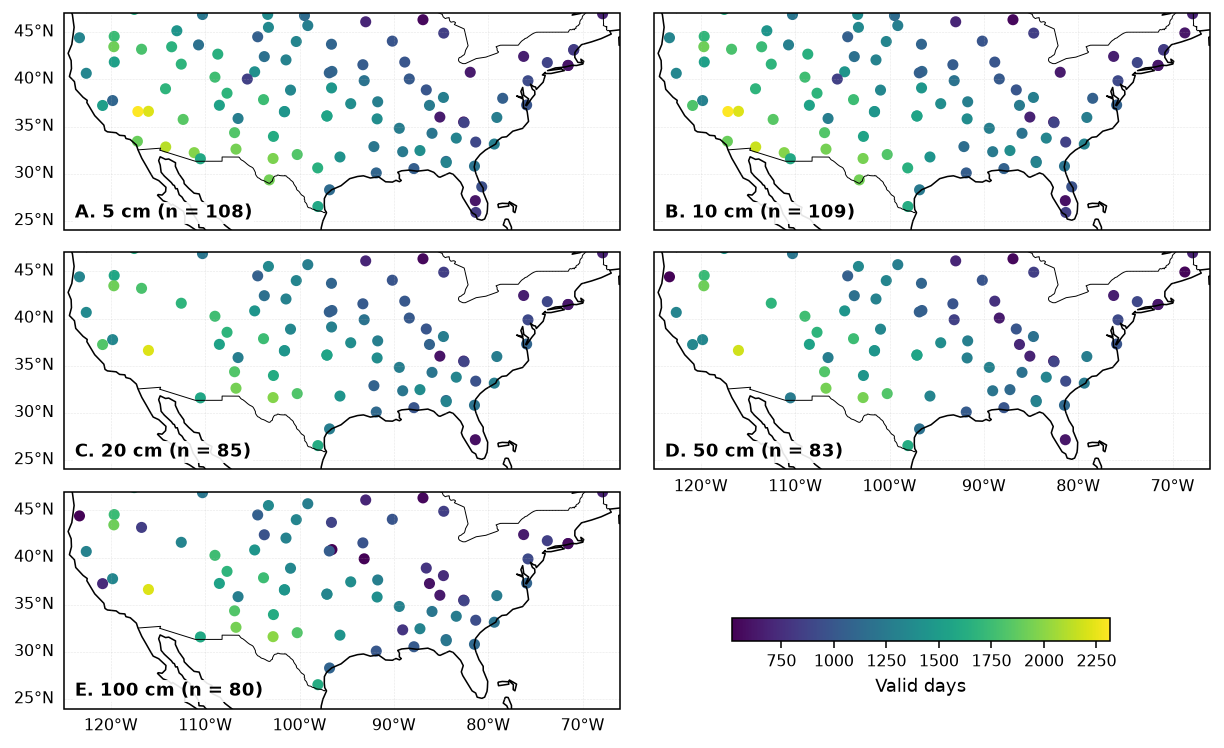

In [13]:
cols = SENSOR_COLS
titles = [DEPTH_LABEL[c] for c in cols]
min_points_map = 500

ncols, nrows = 2, 3

# shared color scale across all depths, using only sites that are plotted
plotted = depth_counts[cols].where(depth_counts[cols] > min_points_map)
vmin = plotted.min().min()
vmax = plotted.max().max()

fig, axes = plt.subplots(
    nrows, ncols, figsize=(9, 5.4),
    subplot_kw={'projection': ccrs.PlateCarree()},
)
axes = axes.ravel()

for i, (ax, col, title) in enumerate(zip(axes, cols, titles)):
    subset = depth_counts[depth_counts[col] > min_points_map]
    n_sites = len(subset)
    print(f"{title}: n = {n_sites}")  # <-- prints for caption

    sc = ax.scatter(
        subset["lon"], subset["lat"], c=subset[col],
        s=22, vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree()
    )
    ax.coastlines(resolution='110m', linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.set_extent([-125, -66, 24, 47], crs=ccrs.PlateCarree())

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.3, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.geo_labels = False                            # avoids cartopy's singular-transform path
    gl.left_labels = (i % ncols == 0)                # left column only
    gl.bottom_labels = (i >= len(cols) - ncols)      # bottom-most panel in each column
    gl.xlocator = plt.FixedLocator(np.arange(-120, -60, 10))
    gl.ylocator = plt.FixedLocator(np.arange(25, 50, 5))
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}

    # ---- PANEL LABEL WITH DEPTH + N ----
    ax.text(
        0.02, 0.04, f"{chr(65 + i)}. {title} (n = {n_sites})",
        transform=ax.transAxes, fontsize=9, fontweight='bold', va='bottom',
        bbox=dict(facecolor="white", alpha=0.9, edgecolor="none", pad=1)
    )

# remove the unused 6th panel (an empty GeoAxes has a degenerate transform)
for ax in axes[len(cols):]:
    fig.delaxes(ax)

# explicit spacing instead of tight_layout (unreliable with cartopy's fixed aspect)
fig.subplots_adjust(left=0.07, right=0.98, bottom=0.06, top=0.98,
                    wspace=0.06, hspace=0.10)

# horizontal colorbar in the vacant sixth slot
cbar_ax = fig.add_axes([0.60, 0.15, 0.30, 0.030])
cbar = fig.colorbar(sc, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Valid days", fontsize=9)
cbar_ax.tick_params(labelsize=8)

fig.savefig(FIG_DIR / f"FigureS1_data_availability_{SUFFIX}.png", dpi=300)
plt.show()

# Figure 1. Representiveness boxplot across timescales


=== FIGURE 1: SM5 REPRESENTATIVENESS ===

--- Daily ---
    10 cm: median r = 0.93, std = 0.12, n = 126
    20 cm: median r = 0.85, std = 0.20, n = 101
    50 cm: median r = 0.65, std = 0.26, n = 100
   100 cm: median r = 0.48, std = 0.26, n = 98

--- Weekly ---
    10 cm: median r = 0.93, std = 0.11, n = 127
    20 cm: median r = 0.86, std = 0.20, n = 102
    50 cm: median r = 0.67, std = 0.27, n = 101
   100 cm: median r = 0.51, std = 0.26, n = 96

--- Monthly ---
    10 cm: median r = 0.94, std = 0.14, n = 123
    20 cm: median r = 0.89, std = 0.22, n = 99
    50 cm: median r = 0.75, std = 0.30, n = 98
   100 cm: median r = 0.54, std = 0.28, n = 91

--- Seasonal ---
    10 cm: median r = 0.90, std = 0.21, n = 114
    20 cm: median r = 0.87, std = 0.29, n = 90
    50 cm: median r = 0.73, std = 0.36, n = 88
   100 cm: median r = 0.60, std = 0.40, n = 88



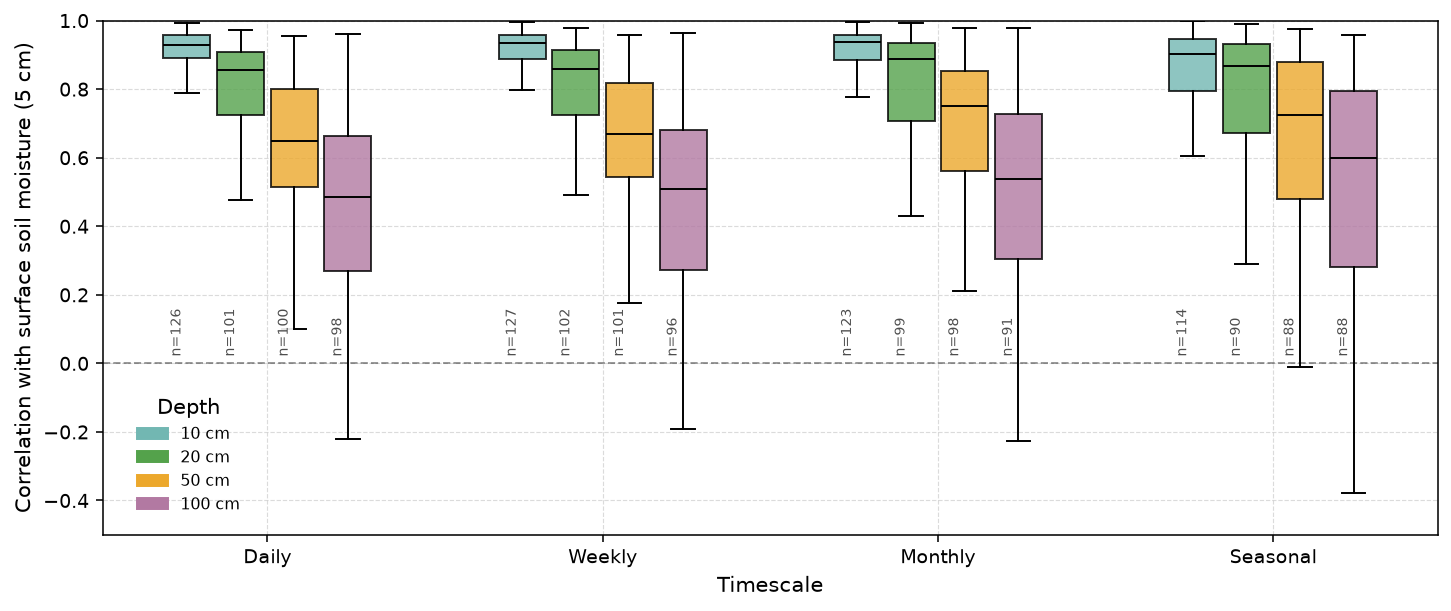

In [14]:
# =====================================================
# FIGURE 1: REPRESENTATIVENESS OF 5 CM SOIL MOISTURE
# Correlation between SM_5cm and deeper soil moisture
# across timescales
# =====================================================

# assumes you already created:
# corr_sm5_by_scale
# with columns: station_id, depth_cm, timescale, n_periods, r

# --- SUMMARY / COUNTS ---
counts_sm5 = (
    corr_sm5_by_scale
    .groupby(["timescale", "depth"])["station_id"]
    .nunique()
    .reset_index(name="n_stations")
)

timescales = ["Daily", "Weekly", "Monthly", "Seasonal"]

# depths to include in representativeness figure
depths_rep = [c for c in SENSOR_COLS if c != "sm_5"]


# =====================================================
# PRINT SUMMARY STATS (Fig. 1)
# =====================================================

summary_sm5 = (
    corr_sm5_by_scale
    .groupby(["timescale", "depth"])["r"]
    .agg(["median", "mean", "std", "count"])
    .reset_index()
)

print("\n=== FIGURE 1: SM5 REPRESENTATIVENESS ===\n")

for ts in timescales:
    print(f"--- {ts} ---")
    sub = summary_sm5[summary_sm5["timescale"] == ts]

    for depth in depths_rep:
        row = sub[sub["depth"] == depth]

        if len(row) == 0:
            continue

        med = row["median"].values[0]
        std = row["std"].values[0]
        n = int(row["count"].values[0])

        print(f"{DEPTH_LABEL[depth]:>9}: median r = {med:.2f}, std = {std:.2f}, n = {n}")

    print("")

# use same centers/offset logic as Fig. 2
fig, ax = plt.subplots(1, 1, figsize=(10.5, 4.5))

group_centers = np.arange(len(timescales))
offsets = np.linspace(-0.24, 0.24, len(depths_rep))
width = 0.14

for offset, depth in zip(offsets, depths_rep):
    data = []
    positions = []

    for i, ts in enumerate(timescales):
        vals = corr_sm5_by_scale.loc[
            (corr_sm5_by_scale["timescale"] == ts) &
            (corr_sm5_by_scale["depth"] == depth),
            "r"
        ].dropna().values

        data.append(vals)
        positions.append(group_centers[i] + offset)

    bp = ax.boxplot(
        data,
        positions=positions,
        widths=width,
        patch_artist=True,
        manage_ticks=False,
        showfliers=False,
    )

    for patch in bp["boxes"]:
        patch.set_facecolor(DEPTH_COLOR[depth])
        patch.set_alpha(0.8)

    for element in ["whiskers", "caps", "medians"]:
        for artist in bp[element]:
            artist.set_color("black")

# --- labels / axes ---
ax.set_xticks(group_centers)
ax.set_xticklabels(timescales)
ax.set_ylabel(r"Correlation with surface soil moisture (5 cm)")
ax.set_xlabel("Timescale")
ax.set_ylim(-0.5, 1)
ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.4)

# --- n labels ---
for i, ts in enumerate(timescales):
    for offset, depth in zip(offsets, depths_rep):
        n = counts_sm5.loc[
            (counts_sm5["timescale"] == ts) &
            (counts_sm5["depth"] == depth),
            "n_stations"
        ]
        if len(n) == 0:
            continue

        ax.text(
            group_centers[i] + offset - 0.03,
            0.02,
            f"n={int(n.values[0])}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90,
            color="0.3",
            bbox=dict(facecolor="white", alpha=0.9, edgecolor="none", pad=1)
        )

# --- legend ---
handles = [mpatches.Patch(color=DEPTH_COLOR[d], label=DEPTH_LABEL[d]) for d in depths_rep]
ax.legend(
    handles=handles,
    title="Depth",
    loc="lower left",
    bbox_to_anchor=(0.015, 0.015),
    frameon=False,
    fontsize=8
    
)

# --- grid styling ---
ax.grid(
    True,
    which="major",
    linestyle="--",
    linewidth=0.6,
    color="0.8",
    alpha=0.7
)
ax.set_axisbelow(True)

# --- finalize ---
fig.tight_layout()
fig.savefig(
    FIG_DIR / f"Figure1_representativeness_sm5_by_timescale_{SUFFIX}.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Figure 2. Grouped boxplot across timescales


Median coupling statistics by timescale and depth:
timescale    depth  median_r  median_r2  n_stations
    Daily sm_0_100 -0.246774   0.060949          96
    Daily  sm_0_20 -0.318270   0.101296         101
    Daily    sm_10 -0.294717   0.086859         126
    Daily   sm_100 -0.100444   0.014717          98
    Daily    sm_20 -0.259728   0.067458         101
    Daily     sm_5 -0.327908   0.107524         126
    Daily    sm_50 -0.188656   0.037858         100
  Monthly sm_0_100 -0.299273   0.112102          90
  Monthly  sm_0_20 -0.456146   0.208069          99
  Monthly    sm_10 -0.442638   0.195929         123
  Monthly   sm_100 -0.125406   0.027804          91
  Monthly    sm_20 -0.362144   0.155503          99
  Monthly     sm_5 -0.460493   0.212054         123
  Monthly    sm_50 -0.256271   0.080047          98
 Seasonal sm_0_100 -0.453525   0.224508          87
 Seasonal  sm_0_20 -0.552619   0.305389          90
 Seasonal    sm_10 -0.465406   0.224655         114
 Seasonal   

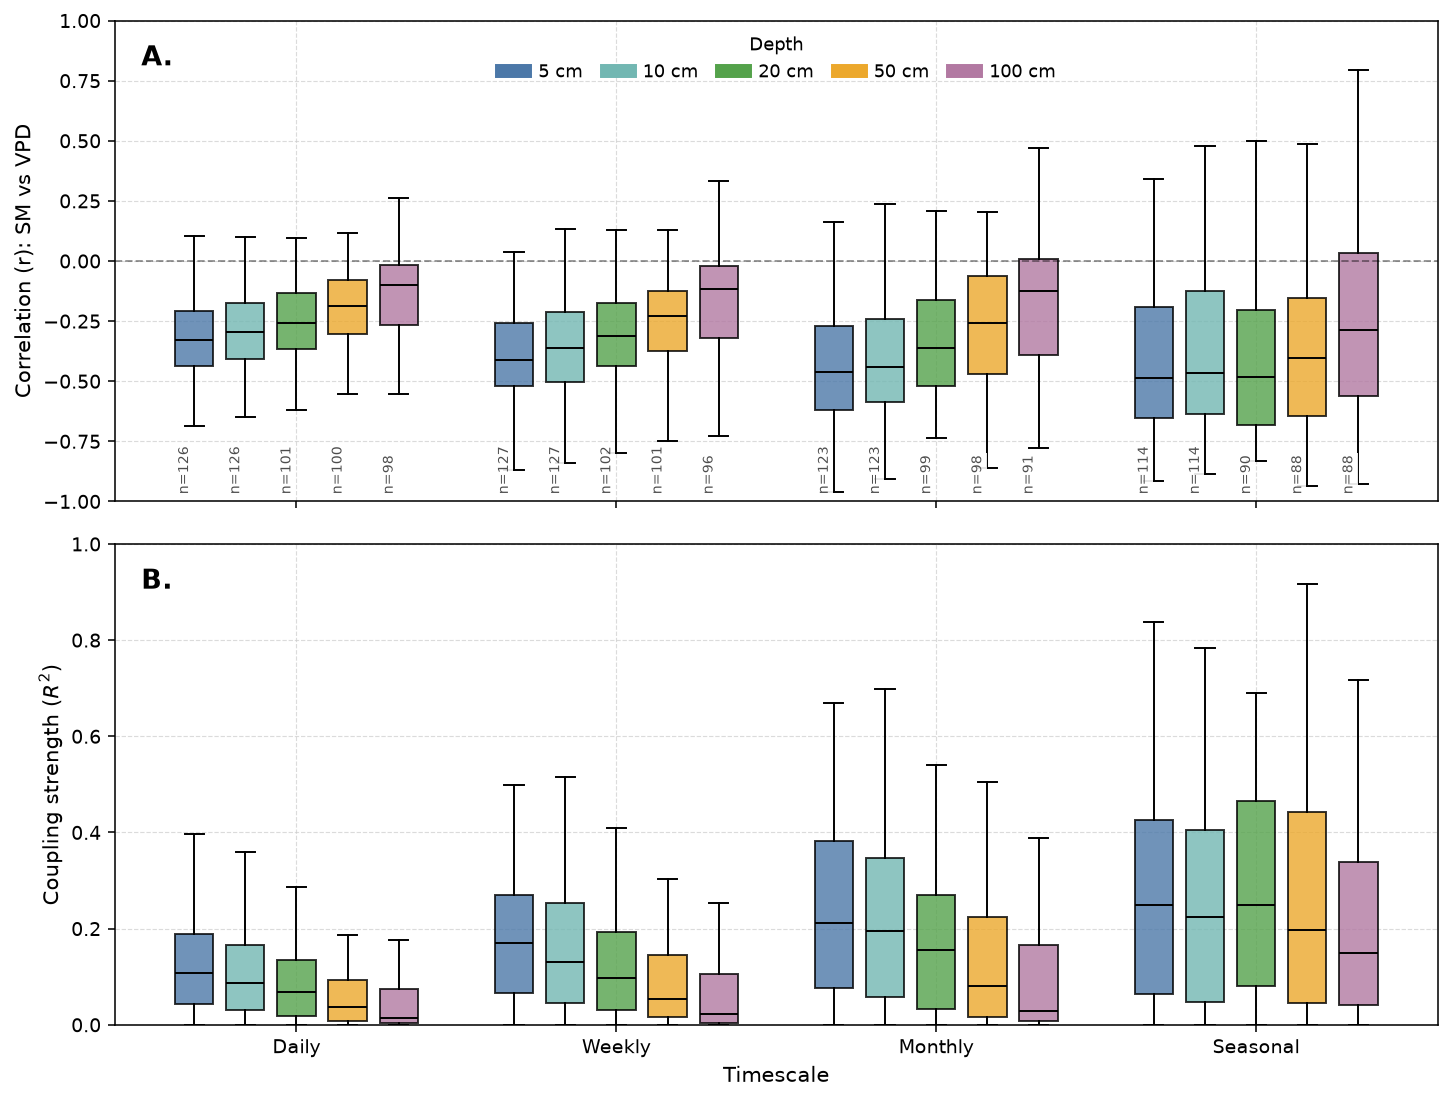

In [15]:
# --- PREP ---
plot_cols = SENSOR_COLS          # swap to ALL_COLS for the SI version
corr_by_scale["r2"] = corr_by_scale["r"]**2


# --- SUMMARY NUMBERS TO REPORT ---
summary_stats = (
    corr_by_scale
    .groupby(["timescale", "depth"])
    .agg(
        median_r=("r", "median"),
        median_r2=("r2", "median"),
        n_stations=("station_id", "nunique")
    )
    .reset_index()
)

print("\nMedian coupling statistics by timescale and depth:")
print(summary_stats.to_string(index=False))

# --- specific numbers for text (5 cm vs 100 cm, daily vs seasonal) ---
key_stats = summary_stats[
    summary_stats["depth"].isin(["sm_5", "sm_100"]) &
    summary_stats["timescale"].isin(["Daily", "Seasonal"])
].copy()

print("\nKey text values (5 cm vs 100 cm; Daily vs Seasonal):")
print(key_stats.to_string(index=False))

# --- compare timescale effect vs depth effect using median R² ---
r2_5_daily = summary_stats.loc[
    (summary_stats["timescale"] == "Daily") & (summary_stats["depth"] == "sm_5"),
    "median_r2"
].values[0]

r2_5_seasonal = summary_stats.loc[
    (summary_stats["timescale"] == "Seasonal") & (summary_stats["depth"] == "sm_5"),
    "median_r2"
].values[0]

r2_100_seasonal = summary_stats.loc[
    (summary_stats["timescale"] == "Seasonal") & (summary_stats["depth"] == "sm_100"),
    "median_r2"
].values[0]

timescale_effect = r2_5_seasonal - r2_5_daily
depth_effect = r2_5_seasonal - r2_100_seasonal

print("\nEffect size comparison using median R²:")
print(f"5 cm: Daily to Seasonal increase = {timescale_effect:.3f}")
print(f"Seasonal: 5 cm to 100 cm decrease = {depth_effect:.3f}")

counts = (
    corr_by_scale
    .groupby(["timescale", "depth"])["station_id"]
    .nunique()
    .reset_index(name="n_stations")
)

timescales = ["Daily", "Weekly", "Monthly", "Seasonal"]

# --- FIGURE SETUP (STACKED) ---
fig, axes = plt.subplots(2, 1, figsize=(10.5, 8), sharex=True)

group_centers = np.arange(len(timescales))
offsets = np.linspace(-0.32, 0.32, len(plot_cols))
width = 0.12

# =====================================================
# PANEL A: SIGNED CORRELATION (r)
# =====================================================
ax = axes[0]

for offset, depth in zip(offsets, plot_cols):
    data = []
    positions = []

    for i, ts in enumerate(timescales):
        vals = corr_by_scale.loc[
            (corr_by_scale["timescale"] == ts) &
            (corr_by_scale["depth"] == depth),
            "r"
        ].dropna().values

        data.append(vals)
        positions.append(group_centers[i] + offset)

    bp = ax.boxplot(
        data,
        positions=positions,
        widths=width,
        patch_artist=True,
        manage_ticks=False,
        showfliers=False,
    )

    for patch in bp["boxes"]:
        patch.set_facecolor(DEPTH_COLOR[depth])
        patch.set_alpha(0.8)

    for element in ["whiskers", "caps", "medians"]:
        for artist in bp[element]:
            artist.set_color("black")

# Labels
ax.set_ylabel("Correlation (r): SM vs VPD")
ax.set_ylim(-1, 1)
ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.4)
# ax.set_title("A. Signed coupling")
ax.text(
    0.02, 0.95,
    "A.",
    transform=ax.transAxes,
    fontsize=14,
    fontweight='bold',
    ha='left',
    va='top',
    bbox=dict(facecolor="white", alpha=0.9, edgecolor="none", pad=1)
)


# --- n labels ONLY on panel A ---
for i, ts in enumerate(timescales):
    for offset, depth in zip(offsets, plot_cols):
        n = counts.loc[
            (counts["timescale"] == ts) &
            (counts["depth"] == depth),
            "n_stations"
        ]
        if len(n) == 0:
            continue

        ax.text(
            group_centers[i] + offset - 0.03,
            -0.97,
            f"n={int(n.values[0])}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90,
            color="0.3",
            bbox=dict(facecolor="white", alpha=0.9, edgecolor="none", pad=1)
        )

# then the legend, still on panel A:
handles = [mpatches.Patch(color=DEPTH_COLOR[d], label=DEPTH_LABEL[d]) for d in plot_cols]
ax.legend(
    handles=handles,
    title="Depth",
    loc="upper center",
    ncol=len(plot_cols),
    frameon=False,
    fontsize=9,
    title_fontsize=9,
    columnspacing=1.0,
    handletextpad=0.4,
)


# =====================================================
# PANEL B: COUPLING STRENGTH (R²)
# =====================================================
ax = axes[1]

for offset, depth in zip(offsets, plot_cols):
    data = []
    positions = []

    for i, ts in enumerate(timescales):
        vals = corr_by_scale.loc[
            (corr_by_scale["timescale"] == ts) &
            (corr_by_scale["depth"] == depth),
            "r2"
        ].dropna().values

        data.append(vals)
        positions.append(group_centers[i] + offset)

    bp = ax.boxplot(
        data,
        positions=positions,
        widths=width,
        patch_artist=True,
        manage_ticks=False,
        showfliers=False,
    )

    for patch in bp["boxes"]:
        patch.set_facecolor(DEPTH_COLOR[depth])
        patch.set_alpha(0.8)

    for element in ["whiskers", "caps", "medians"]:
        for artist in bp[element]:
            artist.set_color("black")

# Labels
ax.set_xticks(group_centers)
ax.set_xticklabels(timescales)
ax.set_ylabel(r"Coupling strength ($R^2$)")
ax.set_xlabel("Timescale")
ax.set_ylim(-0, 1)
# ax.set_title("B. Magnitude of coupling")

ax.text(
    0.02, 0.95,
    "B.",
    transform=ax.transAxes,
    fontsize=14,
    fontweight='bold',
    ha='left',
    va='top',
    bbox=dict(facecolor="white", alpha=0.9, edgecolor="none", pad=1)
)

for ax in axes:
    ax.grid(
        True,
        which="major",
        linestyle="--",
        linewidth=0.6,
        color="0.8",
        alpha=0.7
    )
    ax.set_axisbelow(True)
# =====================================================
# FINALIZE
# =====================================================
fig.tight_layout()
fig.savefig(FIG_DIR / f"Figure2_coupling_r_and_r2_stacked_{len(plot_cols)}depths_{SUFFIX}.png", dpi=300, bbox_inches="tight")
plt.show()

# Figure 3. Joint SM–VPD distributions by depth

/var/folders/ql/gv0k21w56llc1htbtgq4wzmm0000gn/T/ipykernel_17540/1194225362.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.14, 1, 1])


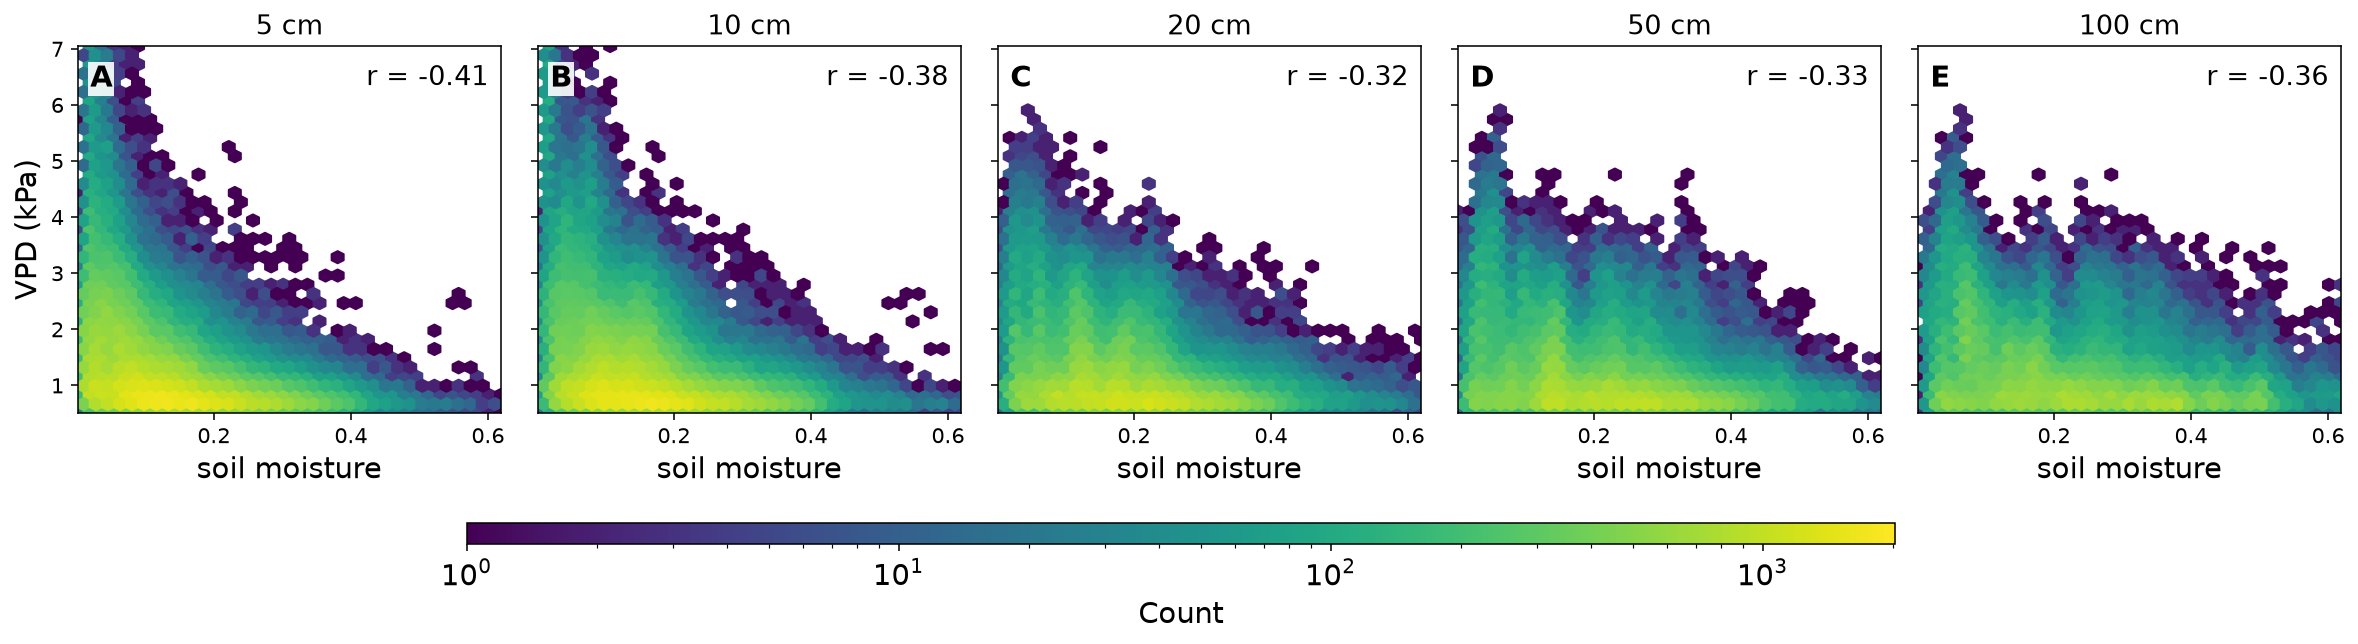

In [16]:
plot_cols = SENSOR_COLS          # swap to ALL_COLS for the SI version

fig, axes = plt.subplots(
    1, len(plot_cols),
    figsize=(3.4 * len(plot_cols), 4.3),
    sharex=True,
    sharey=True
)

if len(plot_cols) == 1:
    axes = [axes]

xlim = (
    np.nanpercentile(long_sm["soil_moisture"], 0),
    np.nanpercentile(long_sm["soil_moisture"], 99.9)
)
ylim = (
    np.nanpercentile(long_sm["vpd"], 0),
    np.nanpercentile(long_sm["vpd"], 99.9)
)

panel_labels = list("ABCDEFG")

all_counts = []
for depth in plot_cols:
    sub = long_sm[long_sm["depth"] == depth]
    x = sub["soil_moisture"].to_numpy()
    y = sub["vpd"].to_numpy()
    mask = np.isfinite(x) & np.isfinite(y)
    H, _, _ = np.histogram2d(x[mask], y[mask], bins=35, range=[xlim, ylim])
    all_counts.append(H)

vmax = max(H.max() for H in all_counts)
norm = LogNorm(vmin=1, vmax=vmax)

for i, (ax, depth) in enumerate(zip(axes, plot_cols)):
    sub = long_sm[long_sm["depth"] == depth]

    h = ax.hexbin(
        sub["soil_moisture"],
        sub["vpd"],
        gridsize=35,
        mincnt=1,
        extent=(xlim[0], xlim[1], ylim[0], ylim[1]),
        norm=norm,
    )

    r = sub["soil_moisture"].corr(sub["vpd"])

    ax.set_title(DEPTH_LABEL[depth], fontsize=14)
    ax.text(0.03, 0.95, panel_labels[i], transform=ax.transAxes,
            ha="left", va="top", fontsize=15, fontweight="bold",bbox=dict(facecolor="white", alpha=0.9, edgecolor="none", pad=1))
    ax.text(0.97, 0.95, f"r = {r:.2f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=14,
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=1))

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.tick_params(labelsize=11)

    if i == 0:
        ax.set_ylabel("VPD (kPa)", fontsize=15)
    ax.set_xlabel("soil moisture", fontsize=15)

cbar_ax = fig.add_axes([0.2, 0.08, 0.6, 0.035])
cbar = fig.colorbar(h, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Count", fontsize=15)
cbar.ax.tick_params(labelsize=15)

# fig.suptitle("Figure 3. Joint SM–VPD distributions by depth", y=1.03, fontsize=16)
fig.tight_layout(rect=[0, 0.14, 1, 1])
fig.savefig(FIG_DIR / f"Figure3_joint_distributions_by_depth_{len(plot_cols)}depths_{SUFFIX}.png", dpi=300, bbox_inches="tight")
plt.show()

# Figure 4. Synthetic depth mismatch (top row only)



--- KEY NUMBERS FROM SYNTHETIC EXPERIMENT ---

Model fit when depth is correct (diagonal R²):
  5 cm: R² = 1.00
  10 cm: R² = 1.00
  20 cm: R² = 1.00
  50 cm: R² = 1.00
  100 cm: R² = 1.00
  Mean diagonal R²: 1.00

Model fit under strong mismatch:
  True 5 cm vs far depth → R² = 0.49
  True 10 cm vs far depth → R² = 0.53
  True 20 cm vs far depth → R² = 0.63
  True 50 cm vs far depth → R² = 0.74
  True 100 cm vs far depth → R² = 0.55
  Mean mismatch R²: 0.59

Soil moisture coefficient bias (examples):
  True 100 cm, measured 5 cm → β_sm = 0.46
  True 5 cm, measured 100 cm → β_sm = 0.43

VPD coefficient compensation (examples):
  True 100 cm, measured 5 cm → β_vpd = 1.02
  True 5 cm, measured 100 cm → β_vpd = 0.76


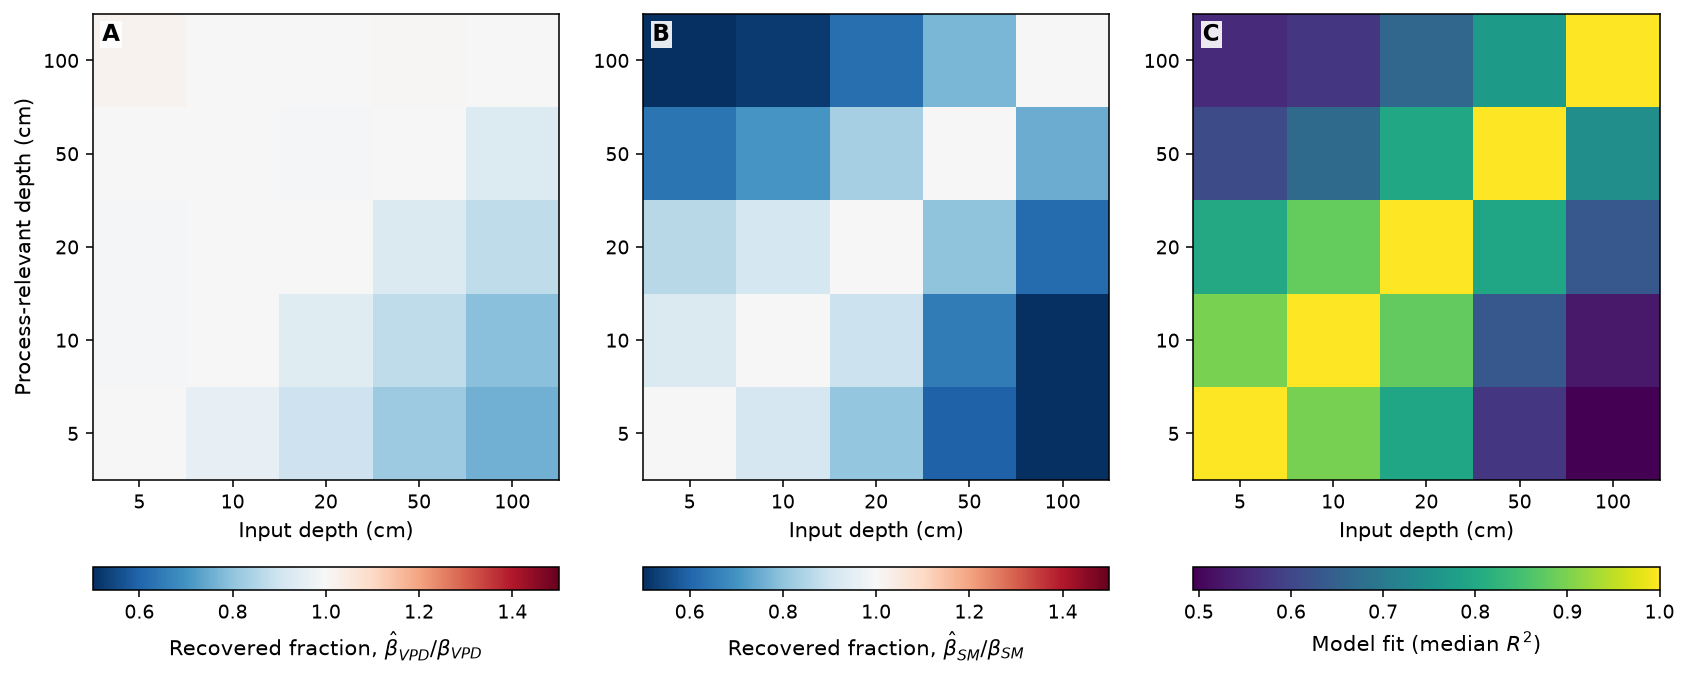

In [17]:
from matplotlib.colors import TwoSlopeNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Pivot tables
plot_cols = SENSOR_COLS          # swap to ALL_COLS for the SI version

def _pivot(values):
    return (synthetic_summary
            .pivot(index="true_depth", columns="input_depth", values=values)
            .reindex(index=plot_cols, columns=plot_cols))   # keep depth order, not alphabetical

pivot_vpd = _pivot("beta_vpd")
pivot_sm  = _pivot("beta_sm")
pivot_r2  = _pivot("r2")

print("\n--- KEY NUMBERS FROM SYNTHETIC EXPERIMENT ---")

depths = list(pivot_r2.index)

# 1. Perfect match (diagonal)
diag_r2 = [pivot_r2.loc[d, d] for d in depths]
print("\nModel fit when depth is correct (diagonal R²):")
for d, val in zip(depths, diag_r2):
    print(f"  {DEPTH_LABEL[d]}: R² = {val:.2f}")

print(f"  Mean diagonal R²: {np.mean(diag_r2):.2f}")

# 2. Worst mismatch (max distance)
max_mismatch_r2 = []
for d in depths:
    far_depth = depths[0] if d == depths[-1] else depths[-1]
    val = pivot_r2.loc[d, far_depth]
    max_mismatch_r2.append(val)

print("\nModel fit under strong mismatch:")
for d, val in zip(depths, max_mismatch_r2):
    print(f"  True {DEPTH_LABEL[d]} vs far depth → R² = {val:.2f}")

print(f"  Mean mismatch R²: {np.mean(max_mismatch_r2):.2f}")

# 3. SM coefficient bias (shallow vs deep mismatch)
print("\nSoil moisture coefficient bias (examples):")
print(f"  True 100 cm, measured 5 cm → β_sm = {pivot_sm.loc['sm_100', 'sm_5']:.2f}")
print(f"  True 5 cm, measured 100 cm → β_sm = {pivot_sm.loc['sm_5', 'sm_100']:.2f}")

# 4. VPD compensation
print("\nVPD coefficient compensation (examples):")
print(f"  True 100 cm, measured 5 cm → β_vpd = {pivot_vpd.loc['sm_100', 'sm_5']:.2f}")
print(f"  True 5 cm, measured 100 cm → β_vpd = {pivot_vpd.loc['sm_5', 'sm_100']:.2f}")

def plot_heatmap(ax, df_summary, value_col, cbar_label, panel_label, cmap=None, show_ylabel=True):
    pivot = (df_summary
             .pivot(index="true_depth", columns="input_depth", values=value_col)
             .reindex(index=plot_cols, columns=plot_cols))
    
    if value_col in ["beta_vpd", "beta_sm"]:
        norm = TwoSlopeNorm(vmin=0.5, vcenter=1.0, vmax=1.5)
        im = ax.imshow(pivot.values, origin="lower", aspect="equal", cmap="RdBu_r", norm=norm)
    else:
        im = ax.imshow(pivot.values, origin="lower", aspect="equal", cmap="viridis")

    DEPTH_TICK = {k: v["label"].replace(" cm", "") for k, v in DEPTHS.items()}
    
    ax.set_xticks(range(len(pivot.columns)),
                  labels=[DEPTH_TICK[c] for c in pivot.columns])
    ax.set_yticks(range(len(pivot.index)),
                  labels=[DEPTH_TICK[c] for c in pivot.index])
    ax.set_xlabel("Input depth (cm)")
    if show_ylabel:
        ax.set_ylabel("Process-relevant depth (cm)")

    n = sum(c in SENSOR_COLS for c in pivot.columns)
    if n < len(pivot.columns):
        xlim, ylim = ax.get_xlim(), ax.get_ylim()
        ax.plot([n-0.5, n-0.5], [-0.5, n-0.5], color="k", lw=1.6)   # vertical, below the corner
        ax.plot([-0.5, n-0.5], [n-0.5, n-0.5], color="k", lw=1.6)   # horizontal, left of the corner
        ax.set_xlim(xlim); ax.set_ylim(ylim)
        
    # Panel label
    ax.text(
        0.02, 0.98, panel_label,
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        va="top",
        ha="left",
        bbox=dict(facecolor="white", alpha=0.9, edgecolor="none", pad=1)
    )

    cax = make_axes_locatable(ax).append_axes("bottom", size="5%", pad=0.62)
    cb = ax.figure.colorbar(im, cax=cax, orientation="horizontal")
    cb.set_label(cbar_label)
    
    return im
    

fig, axes = plt.subplots(1, 3, figsize=(12, 4.2), constrained_layout=True)
plot_heatmap(axes[0], synthetic_summary, "beta_vpd",
             r"Recovered fraction, $\hat\beta_{VPD}/\beta_{VPD}$", "A")
plot_heatmap(axes[1], synthetic_summary, "beta_sm",
             r"Recovered fraction, $\hat\beta_{SM}/\beta_{SM}$", "B", show_ylabel=False)
plot_heatmap(axes[2], synthetic_summary, "r2",
             r"Model fit (median $R^2$)", "C", show_ylabel=False)
fig.savefig(FIG_DIR / f"Figure4_synthetic_mismatch_toprow_{len(plot_cols)}depths_{SUFFIX}.png", dpi=300, bbox_inches="tight")
plt.show()

## Save summary tables for later use

In [18]:
print("Saved figure files to:", FIG_DIR)
print("Saved summary tables to:", TAB_DIR)

Saved figure files to: outputs/paper_workflow/figures
Saved summary tables to: outputs/paper_workflow/tables
